# Bitcoin price prediction using SVC and xgboost model

In [1]:
#xgboost- This contain extream gradient boosting machine learning alogrithms which helps to achieve high caauracy on prediction.

#imports laibraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

In [2]:
#importing dataset
df=pd.read_csv('bitcoin.csv')
df.head()


,Date,Open,High,Low,Close,Adj Close,Volume
0,17-09-2014,465.864014,468.174011,452.421997,457.334015,457.334015,21056800.0
1,18-09-2014,456.859985,456.859985,413.104004,424.440002,424.440002,34483200.0
2,19-09-2014,424.102997,427.834991,384.532013,394.795990,394.795990,37919700.0
3,20-09-2014,394.673004,423.295990,389.882996,408.903992,408.903992,36863600.0
4,21-09-2014,408.084991,412.425995,393.181000,398.821014,398.821014,26580100.0


In [3]:
df.shape

(2713, 7)

In [4]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,2713.000000,2713.000000,2713.000000,2713.000000,2713.000000,2.713000e+03
mean,11311.041069,11614.292482,10975.555058,11323.914637,11323.914637,1.470462e+10
std,16106.428892,16537.390649,15608.572561,16110.365010,16110.365010,2.001627e+10
min,176.897003,211.731003,171.509995,178.102997,178.102997,5.914570e+06
25%,606.396973,609.260986,604.109985,606.718994,606.718994,7.991080e+07
50%,6301.569824,6434.617676,6214.220215,6317.609863,6317.609863,5.098183e+09
75%,10452.399410,10762.644530,10202.387700,10462.259770,10462.259770,2.456992e+10
max,67549.734380,68789.625000,66382.062500,67566.828130,67566.828130,3.509680e+11


In [5]:
df.info

<bound method DataFrame.info of             Date          Open          High           Low         Close  \
0     17-09-2014    465.864014    468.174011    452.421997    457.334015   
1     18-09-2014    456.859985    456.859985    413.104004    424.440002   
2     19-09-2014    424.102997    427.834991    384.532013    394.795990   
3     20-09-2014    394.673004    423.295990    389.882996    408.903992   
4     21-09-2014    408.084991    412.425995    393.181000    398.821014   
...          ...           ...           ...           ...           ...   
2708  15-02-2022  42586.464840  44667.218750  42491.035160  44575.203130   
2709  16-02-2022  44578.277340  44578.277340  43456.691410  43961.859380   
2710  17-02-2022  43937.070310  44132.972660  40249.371090  40538.011720   
2711  18-02-2022  40552.132810  40929.152340  39637.617190  40030.976560   
2712  19-02-2022  40022.132810  40246.027340  40010.867190  40126.429690   

         Adj Close        Volume  
0       457.334015  

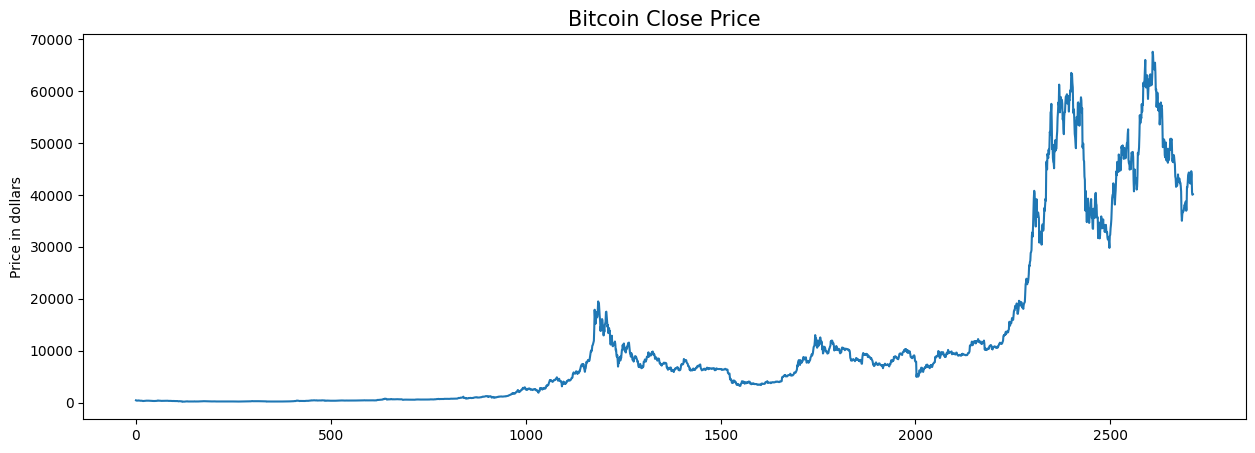

In [6]:
#Expoloratory data analysis
plt.figure(figsize=(15,5))
plt.plot(df['Close'])
plt.title("Bitcoin Close Price",fontsize=15)
plt.ylabel("Price in dollars")
plt.show()

In [7]:
#showing upward trends 
df[df['Close'] == df['Adj Close']].shape, df.shape

((2713, 7), (2713, 7))

In [8]:
#close and adj close has same data, so drop the adj close column
df=df.drop(['Adj Close'], axis=1)

In [9]:
#check data present
df.isnull().sum()

Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

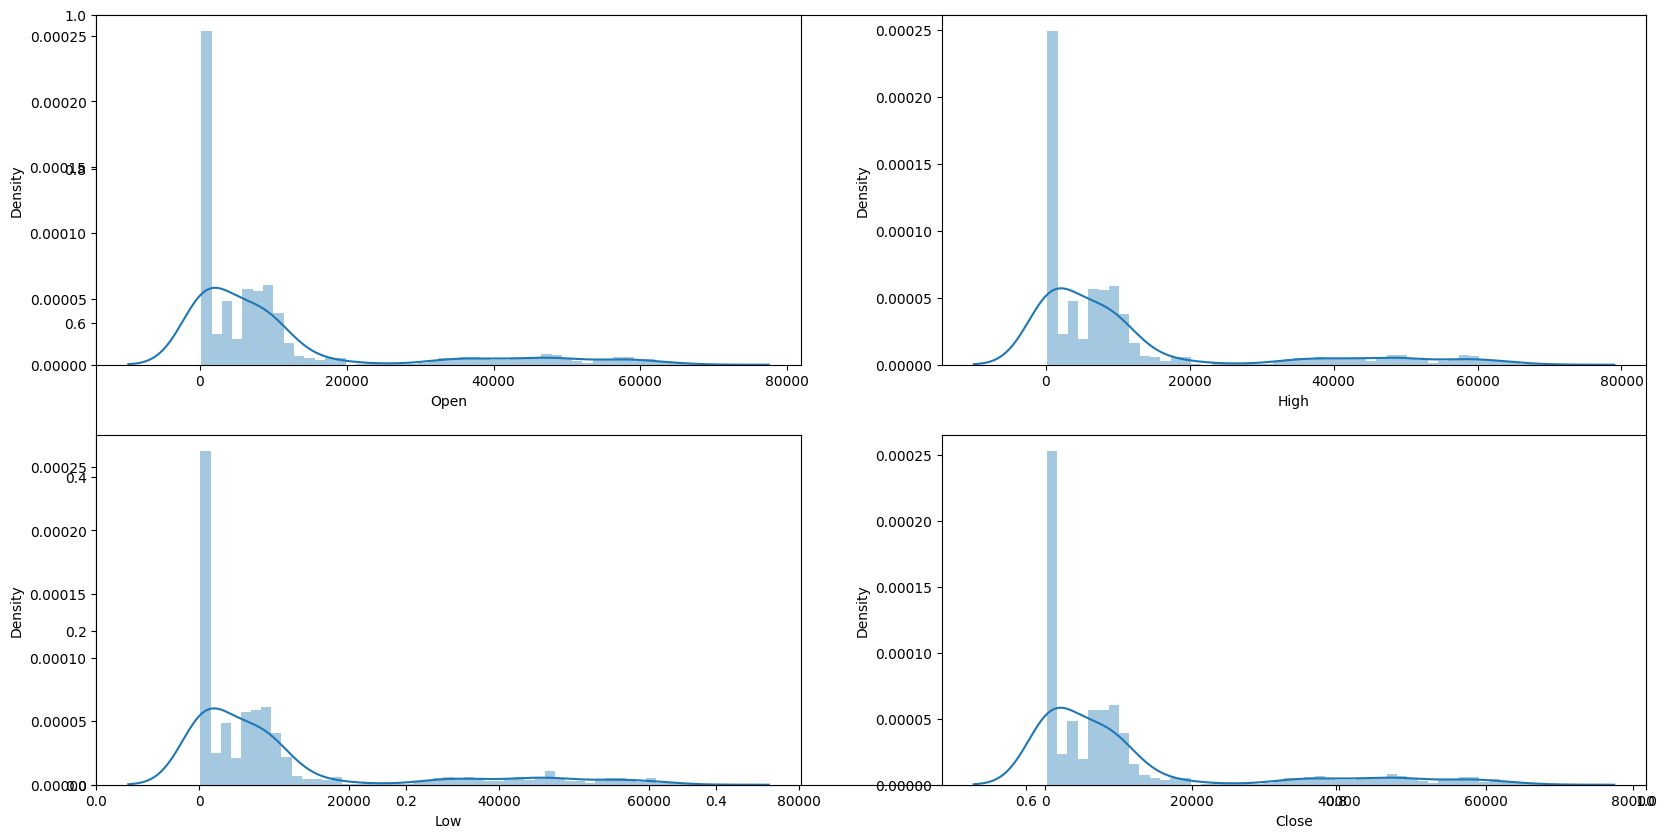

In [10]:
features=['Open','High','Low','Close']
plt.subplots(figsize=(20,10))
for i, col in enumerate(features):
    plt.subplot(2,2,i+1) #no of rows, no of cols
    sns.distplot(df[col])
plt.show()

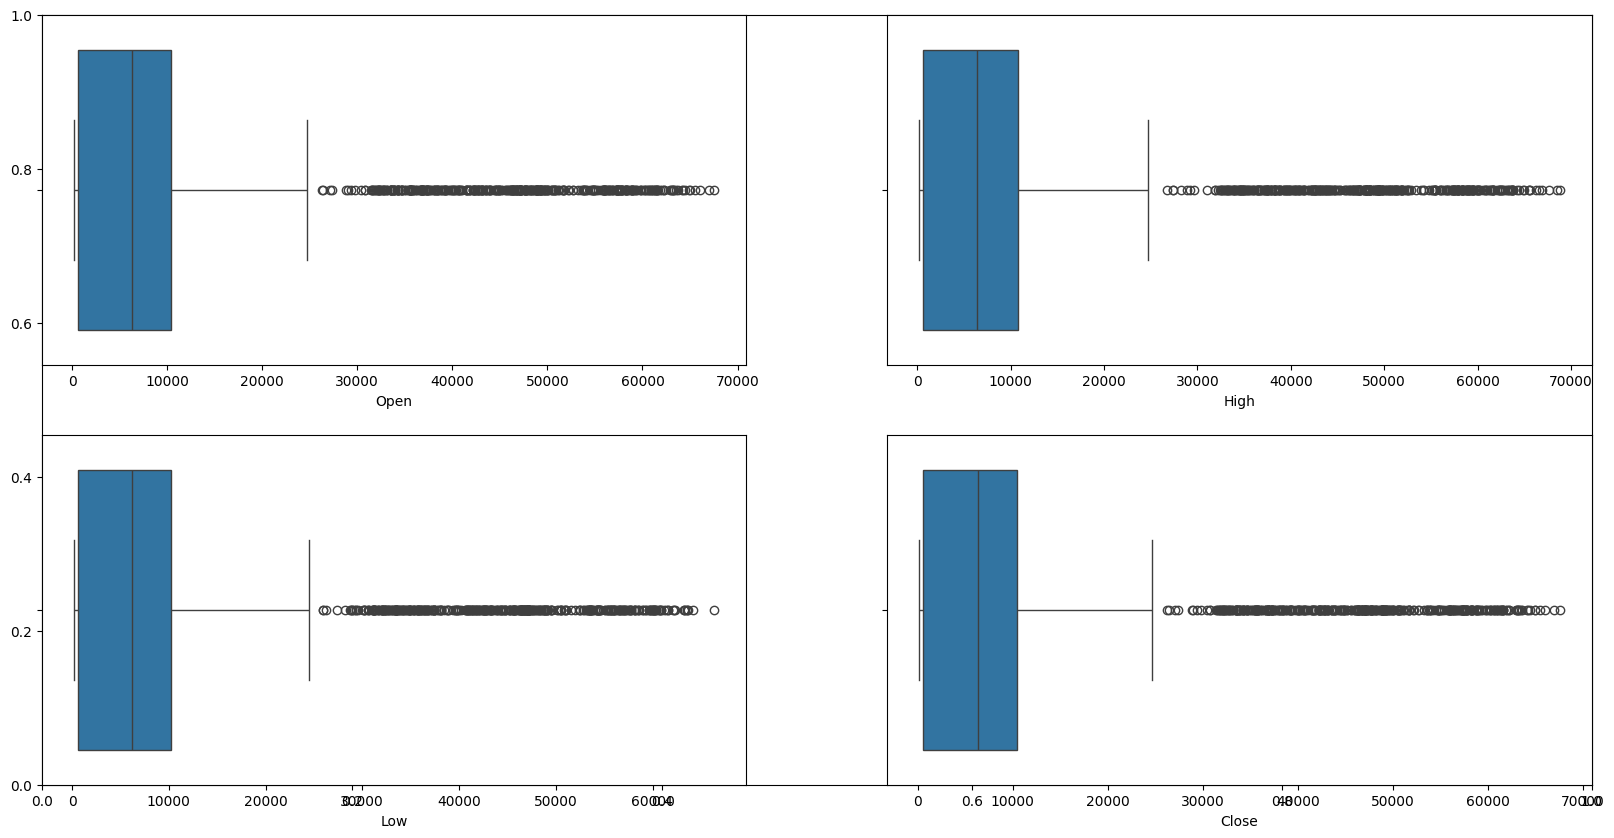

In [11]:
plt.subplots(figsize=(20,10))
for i, col in enumerate(features):
    plt.subplot(2,2,i+1) #no of rows, no of cols
    sns.boxplot(df[col], orient='h')
plt.show()

In [12]:
#feature engineering work
splitted = df ['Date'].str.split('-', expand=True)
df['day']=splitted[0].astype('int')
df['month']=splitted[1].astype('int')
df['year']=splitted[2].astype('int')

#convert the 'Data' coumns to detemineobject
df['Date']=pd.to_datetime(df['Date'])
df.head()

,Date,Open,High,Low,Close,Volume,day,month,year
0,2014-09-17,465.864014,468.174011,452.421997,457.334015,21056800.0,17,9,2014
1,2014-09-18,456.859985,456.859985,413.104004,424.440002,34483200.0,18,9,2014
2,2014-09-19,424.102997,427.834991,384.532013,394.795990,37919700.0,19,9,2014
3,2014-09-20,394.673004,423.295990,389.882996,408.903992,36863600.0,20,9,2014
4,2014-09-21,408.084991,412.425995,393.181000,398.821014,26580100.0,21,9,2014


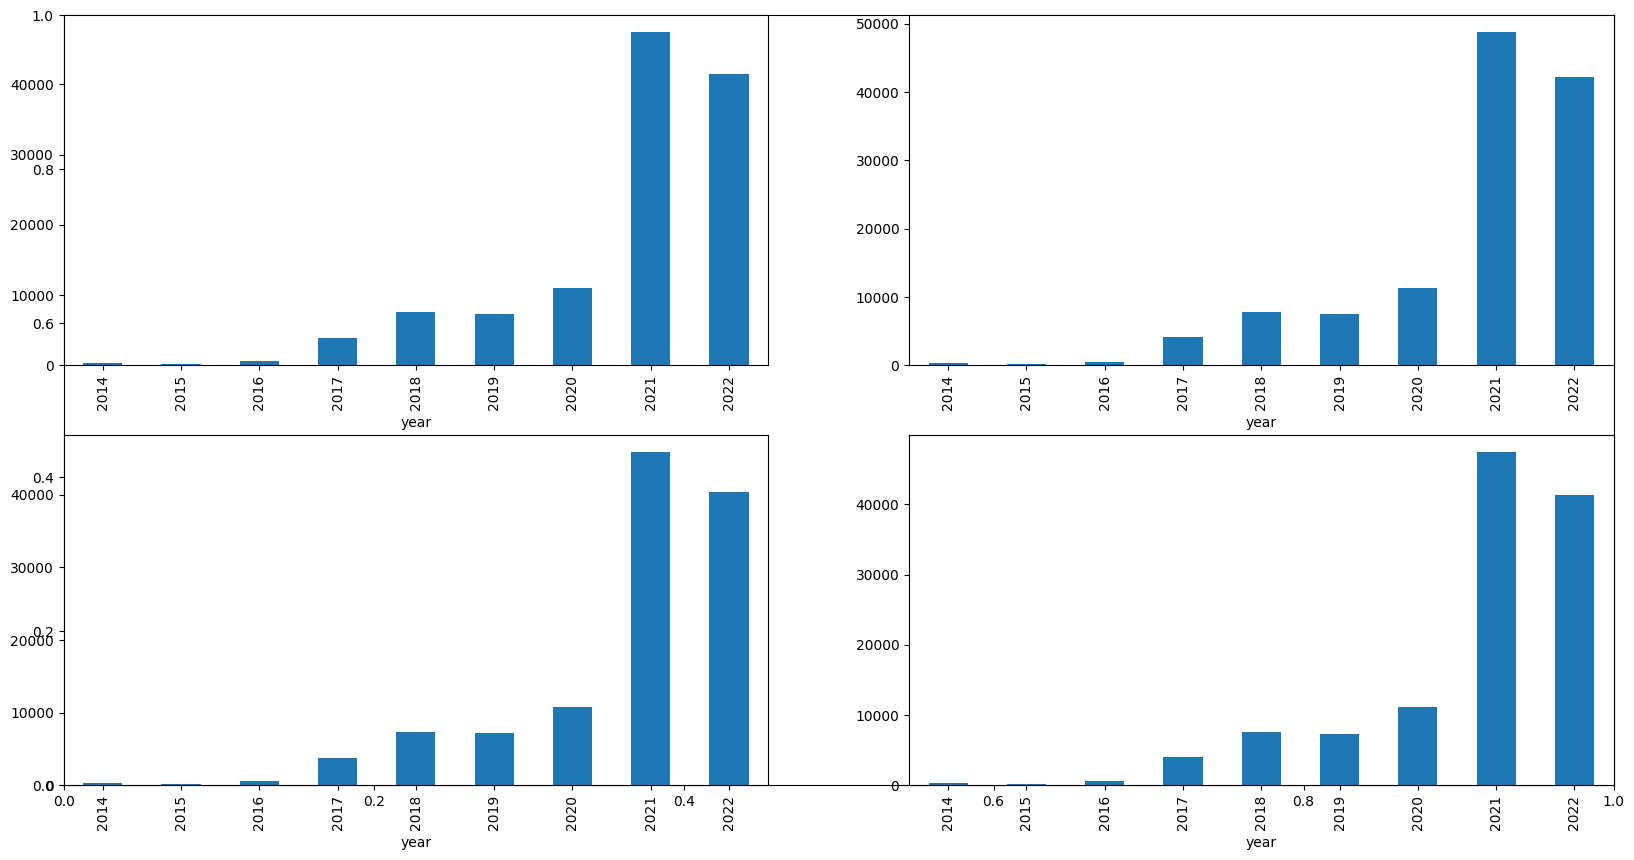

In [15]:
# Now we have three more columns namely 'day', 'month' and 'year' all these three have 
#been derived from the 'Date' column which was initially provided in the data.
data_grouped=df.groupby('year').mean()
plt.subplots(figsize=(20,10))
for i, col in enumerate(['Open','High','Low','Close']):
    plt.subplot(2,2,i+1)
    data_grouped[col].plot.bar()
plt.show()

In [28]:
# Here we can observe why there are so many outliers in the data as the prices of bitcoin have exploded in the year 2021. 
df['is_quarter_end'] = np.where(df['month']%3==0,1,0) 
df.head()
df['open-close']  = df['Open'] - df['Close'] 
df['low-high']  = df['Low'] - df['High'] 
df['target'] = np.where(df['Close'].shift(-1) > df['Close'], 1, 0)

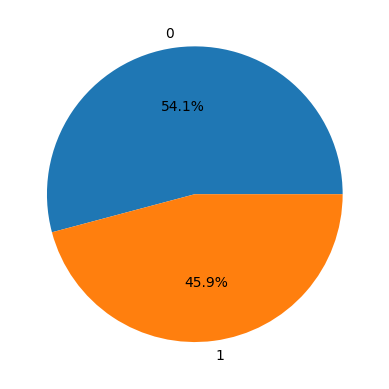

In [29]:
# We have added the target feature which is a signal whether to buy or not we will train our model to predict this only.
#But before proceeding let's check whether the target is balanced or not using a pie chart. 
plt.pie(df['target'].value_counts().values,  
labels=[0, 1], autopct='%1.1f%%') 
plt.show() 

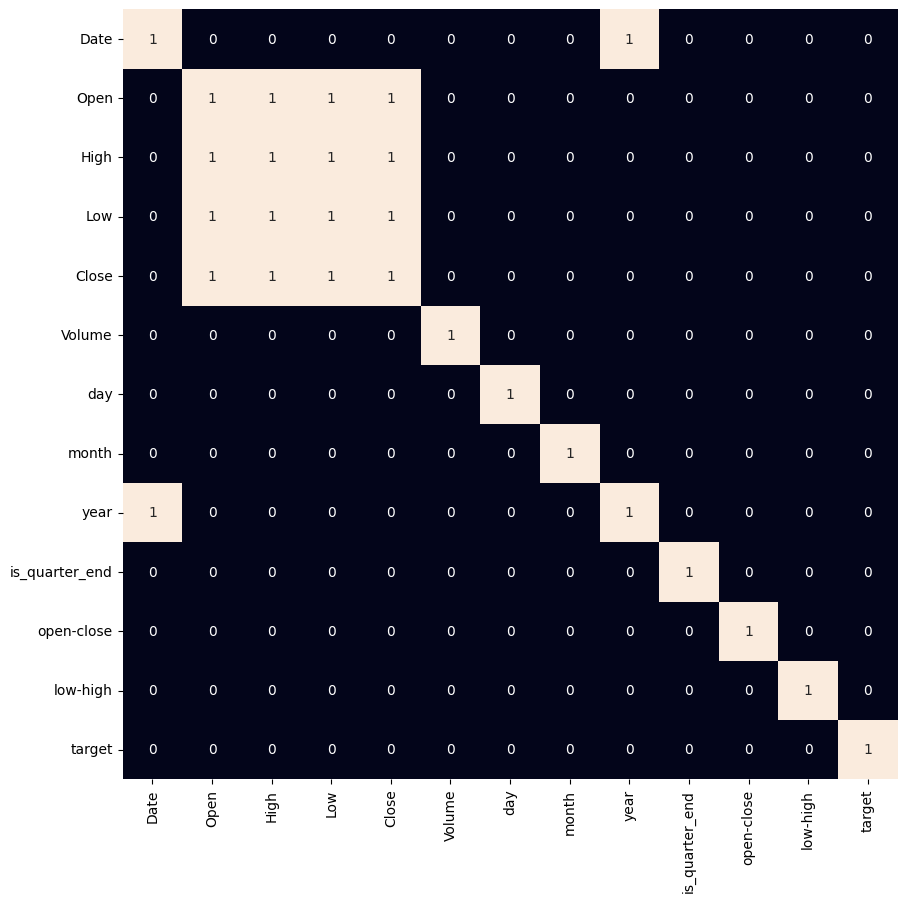

In [30]:
# When we add features to our dataset we have to ensure that there are no highly correlated 
#features as they do not help in the learning process of the algorithm. 
plt.figure(figsize=(10, 10)) 
sns.heatmap(df.corr() > 0.9, annot=True, cbar=False) 
plt.show()

In [20]:
# From the above heatmap, we can say that there is a high correlation between OHLC which 
# is pretty obvious, and the added features are not highly correlated with each other or 
# previously provided features which means that we are good to go and build our model. 
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler 
# Assuming df is already defined 
features = df[['open-close', 'low-high', 'is_quarter_end']] 
target = df['target'] 
# Scaling the features 
scaler = StandardScaler() 
features = scaler.fit_transform(features) 
# Split the data into training and validation (test) sets 
X_train, X_valid, Y_train, Y_valid = train_test_split(features, target, test_size=0.3, 
random_state=42) 
# 'test_size=0.3' means 30% of the data will be used for testing, and 70% for training 

In [26]:
# After selecting the features to train the model on we should normalize the data because normalized data leads to stable and 
# fast training of the model.After that whole data has been split into two parts with a 70/30 ratio so, that we can evaluate the performance of our 
# model on unseen data.For the evaluation metric, we will use the ROC-AUC curve but why this is because instead of 
# predicting the hard probability that is 0 or 1 we would like it to predict soft probabilities 
# that are continuous values between 0 to 1. And with soft probabilities, the ROC-AUC curve 
# isgenerally used to measure the accuracy of the predictions. 
from sklearn import metrics
models = [LogisticRegression(), SVC(kernel='poly', probability=True), XGBClassifier()] 
for i in range(3): 
    models[i].fit(X_train, Y_train) 
    print(f'{models[i]} : ') 
    print('Training Accuracy : ', metrics.roc_auc_score(Y_train, 
models[i].predict_proba(X_train)[:,1])) 
    print('Validation Accuracy : ', metrics.roc_auc_score(Y_valid, 
models[i].predict_proba(X_valid)[:,1])) 
    print()

LogisticRegression() : 
Training Accuracy :  0.5319642853158836
Validation Accuracy :  0.5117827868852459

SVC(kernel='poly', probability=True) : 
Training Accuracy :  0.5340413949430971
Validation Accuracy :  0.5288104996096799

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...) : 
Traini

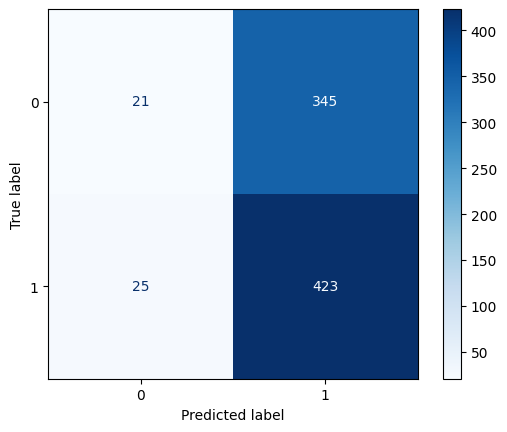

In [27]:
# Among the three models, we have trained XGBClassifier has the highest performance but it 
# is pruned to overfitting as the difference between the training and the validation accuracy is 
# too high. But in the case of the Logistic Regression, this is not the case. 
# Now let's plot a confusion matrix for the validation data. 
from sklearn.metrics import ConfusionMatrixDisplay 
plt.show() 
ConfusionMatrixDisplay.from_estimator(models[0], X_valid, Y_valid, cmap='Blues')